# Building a Trigonometric Function ML Model for the Arduino

**CST-440 – Lecture 3: Machine Learning on a Microcontroller**

Author: *A1* &nbsp;·&nbsp; Date: *9/19/26*

---

## 1. Introduction and Objective

Small neural networks can approximate mathematical functions, and a network small enough can run on a microcontroller. The objective of this project is to **design, train, test and deploy a machine learning model that computes sin(x) and cos(x)** for an angle *x*, and to run it on an Arduino.

The work follows the six steps of the assignment:

1. Design a model architecture
2. Build the model
3. Train the model
4. Build the application
5. Test the application
6. Deploy to a microcontroller

Sections 2–8 below are executable. Run the notebook top to bottom (**Kernel → Restart & Run All**). The only input file needed is `trigdataRAD.csv`, which must be in the same folder as this notebook (on Colab, upload it first).

In [ ]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("GPUs visible:", tf.config.list_physical_devices("GPU"))   # a model this small also trains fine on CPU

# --- Design choices (Step 1) ---
HIDDEN_UNITS = 16      # lecture guidance: 8-16 neurons
N_GENERATED = 2000     # angles generated with numpy, added to the CSV rows
TRAIN_FRAC = 0.70      # train / validation / test split of the combined dataset
VAL_FRAC = 0.15        # (the remaining 15% is the held-out test set)
BATCH_SIZE = 32        # small batch size
MAX_EPOCHS = 500       # upper limit; early stopping ends training sooner if validation loss stops improving
PATIENCE = 30
SEED = 42

# --- Files ---
CSV_PATH = "trigdataRAD.csv"
COMBINED_PATH = "trigdata.csv"
KERAS_PATH = "trig_model.keras"
TFLITE_PATH = "trig_model.tflite"
TFLITE_INT8_PATH = "trig_model_int8.tflite"
HEADER_PATH = "model_data.h"
PLOT_PATH = "training_history.png"

TWO_PI = 2 * np.pi

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"{CSV_PATH} not found - put it in the same folder as this notebook")

TensorFlow version: 2.21.0
GPUs visible: []


## 2. Model Design (Step 1)

**Function.** The model computes both **sin(x)** and **cos(x)**.

**Input / output.**

| | Description |
|---|---|
| Input | one angle *x* in **radians** (1 value) |
| Output | two values: predicted sin(x) and predicted cos(x) |

**Architecture.** A small, efficient fully connected network, following the lecture design:

```
Angle x (radians)
      │
Input layer (1 node)
      │
Hidden layer: 16 neurons, ReLU
      │
Output layer: 2 neurons, linear
      │
[ predicted sin(x), predicted cos(x) ]
```

**Why this design**

- **One hidden layer of 16 ReLU neurons.** sin and cos are smooth, so hundreds of neurons are not needed. Too few neurons underfit; too many waste RAM and flash and slow inference on the microcontroller. The lecture recommends 8–16.
- **ReLU activation.** It trains quickly, is cheap to compute, and works well on embedded hardware.
- **Linear output layer.** sin and cos take negative values, and ReLU would clip them to 0 (for example sin(270°) = −1 would become 0).
- **Size.** The number of parameters is (1×16 + 16) + (16×2 + 2) = **66**, so the model is tiny, converts easily to TensorFlow Lite and fits on an Arduino Nano.

## 3. Dataset

The dataset combines two sources:

- **`trigdataRAD.csv`** – the provided reference table: 25 angles every 15° from 0 to 2π, with sin and cos rounded to 4 decimal places.
- **Generated values** – 2000 angles drawn uniformly at random over one full period [0, 2π], with exact sin and cos values computed with numpy.

The two are combined into **2025 rows**, saved as `trigdata_combined.csv` with only the columns `x`, `sin_x`, `cos_x`, then shuffled and split:

| Split | Share | Purpose |
|---|---|---|
| Train | 70% | fits the weights |
| Validation | 15% | monitored during training for early stopping |
| Test | 15% | never used in training; final, unbiased evaluation |

In [2]:
def trig(x):
    """Targets: column 0 = sin(x), column 1 = cos(x)."""
    return np.column_stack([np.sin(x), np.cos(x)])

rng = np.random.default_rng(SEED)

# 1) The provided table: columns x, sin_x, cos_x (every 15 degrees)
csv_data = np.loadtxt(CSV_PATH, delimiter=",", skiprows=1)
x_csv = csv_data[:, 0].astype(np.float32)
y_csv = csv_data[:, 1:3].astype(np.float32)

# 2) Generated angles, uniform over one full period
x_gen = rng.uniform(0.0, TWO_PI, N_GENERATED).astype(np.float32)
y_gen = trig(x_gen).astype(np.float32)

# 3) Combine, and save (sorted by angle) with only the columns x, sin_x, cos_x
x_all = np.concatenate([x_csv, x_gen])
y_all = np.concatenate([y_csv, y_gen])
is_csv = np.array([True] * len(x_csv) + [False] * len(x_gen))

order = np.argsort(x_all)
with open(COMBINED_PATH, "w") as f:
    f.write("x,sin_x,cos_x\n")
    for xi, (s, c) in zip(x_all[order], y_all[order]):
        f.write(f"{xi:.6f},{s:.6f},{c:.6f}\n")
print(f"Saved {len(x_all)} rows to {COMBINED_PATH}")

# 4) Shuffle, then split into train / validation / test
perm = rng.permutation(len(x_all))
x_all, y_all, is_csv = x_all[perm], y_all[perm], is_csv[perm]

n = len(x_all)
n_train, n_val = int(TRAIN_FRAC * n), int(VAL_FRAC * n)
split = np.array(["train"] * n_train + ["val"] * n_val + ["test"] * (n - n_train - n_val))

def part(name):
    mask = split == name
    return x_all[mask].reshape(-1, 1), y_all[mask]

(X_train, y_train), (X_val, y_val), (X_test, y_test) = part("train"), part("val"), part("test")

print(f"\n{'Split':<12}{'Rows':>6}{'From CSV':>10}{'Generated':>11}")
for name in ("train", "val", "test"):
    mask = split == name
    print(f"{name:<12}{mask.sum():>6}{is_csv[mask].sum():>10}{(~is_csv[mask]).sum():>11}")
print(f"{'total':<12}{n:>6}{is_csv.sum():>10}{(~is_csv).sum():>11}")

Saved 2025 rows to trigdata_combined.csv

Split         Rows  From CSV  Generated
train         1417        14       1403
val            303         8        295
test           305         3        302
total         2025        25       2000


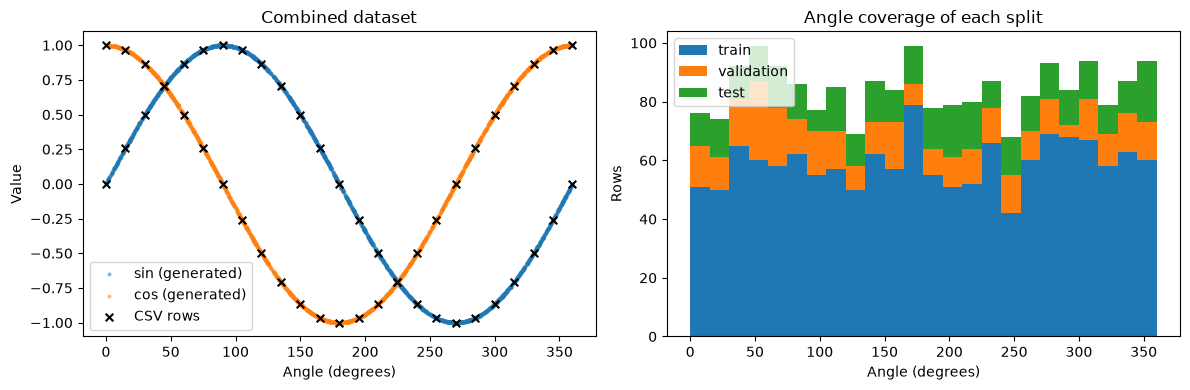

In [3]:
angles_deg = np.rad2deg(x_all)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(angles_deg[~is_csv], y_all[~is_csv, 0], s=4, alpha=0.4, label="sin (generated)")
ax1.scatter(angles_deg[~is_csv], y_all[~is_csv, 1], s=4, alpha=0.4, label="cos (generated)")
ax1.scatter(angles_deg[is_csv], y_all[is_csv, 0], s=30, marker="x", c="k", label="CSV rows")
ax1.scatter(angles_deg[is_csv], y_all[is_csv, 1], s=30, marker="x", c="k")
ax1.set(title="Combined dataset", xlabel="Angle (degrees)", ylabel="Value")
ax1.legend()

ax2.hist([angles_deg[split == s] for s in ("train", "val", "test")], bins=24, stacked=True,
         label=["train", "validation", "test"])
ax2.set(title="Angle coverage of each split", xlabel="Angle (degrees)", ylabel="Rows")
ax2.legend()

fig.tight_layout()
plt.show()

## 4. Building the Model (Step 2)

The model is built with TensorFlow/Keras as described in Section 2.

**Weight initialisation.** Keras' default initialisation (random weights, zero biases) puts every ReLU "kink" at *x* = 0. Because all of our inputs are positive, every hidden neuron with a negative weight is then *dead* from the first step: its output is always 0 and it receives no gradient, so roughly half of the hidden layer never trains. To avoid this, the hidden layer is initialised with its kinks spread evenly across [0, 2π]; training then only has to fine-tune them. This is tested in Section 4.1.

In [4]:
def build_model(spread_init=True):
    """Angle -> Dense(16, ReLU) -> Dense(2, linear) -> [predicted sin(x), predicted cos(x)]"""
    keras.utils.set_random_seed(SEED)
    init_rng = np.random.default_rng(SEED)

    model = keras.Sequential([
        layers.Input(shape=(1,)),                                  # angle in radians
        layers.Dense(HIDDEN_UNITS, activation="relu", name="hidden"),
        layers.Dense(2, activation="linear", name="output"),       # linear: outputs can be negative
    ])

    if spread_init:
        w = init_rng.choice([-1.0, 1.0], HIDDEN_UNITS) * init_rng.uniform(0.5, 1.5, HIDDEN_UNITS)
        kinks = np.linspace(0.0, TWO_PI, HIDDEN_UNITS + 2)[1:-1]
        b = -w * kinks
        model.get_layer("hidden").set_weights(
            [w.reshape(1, HIDDEN_UNITS).astype(np.float32), b.astype(np.float32)]
        )

    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66 (264.00 B)

 Trainable params: 66 (264.00 B)

 Non-trainable params: 0 (0.00 B)

### 4.1 Initialisation experiment

The same architecture is trained for 150 epochs with the default Keras initialisation and with the spread-kink initialisation, and their validation MAE is compared. (This cell takes a minute or so; it is not needed for the rest of the notebook.)

In [5]:
init_results = {}
for spread in (False, True):
    m = build_model(spread_init=spread)
    h = m.fit(X_train, y_train, validation_data=(X_val, y_val),
              batch_size=BATCH_SIZE, epochs=150, verbose=0)
    init_results[spread] = h.history["val_mae"][-1]
    label = "spread-kink init" if spread else "Keras default init"
    print(f"{label:<20} validation MAE after 150 epochs: {init_results[spread]:.5f}")

Keras default init   validation MAE after 150 epochs: 0.17010
spread-kink init     validation MAE after 150 epochs: 0.01242


## 5. Training (Step 3)

| Setting | Value |
|---|---|
| Loss | Mean squared error (MSE) |
| Optimiser | Adam (default learning rate 0.001) |
| Batch size | 32 |
| Maximum epochs | 500 |
| Early stopping | monitor validation loss, patience 30, restore best weights |

In [6]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
progress = keras.callbacks.LambdaCallback(
    on_epoch_end=lambda epoch, logs: print(
        f"epoch {epoch + 1:>4}  loss {logs['loss']:.6f}  val_loss {logs['val_loss']:.6f}  val_mae {logs['val_mae']:.5f}"
    ) if (epoch + 1) % 25 == 0 else None
)

model = build_model()
start = time.perf_counter()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=MAX_EPOCHS,
    callbacks=[early_stop, progress],
    verbose=0,
)
train_seconds = time.perf_counter() - start

epochs_run = len(history.history["loss"])
best_epoch = int(np.argmin(history.history["val_loss"])) + 1
print(f"\nStopped after {epochs_run} epochs (best validation loss at epoch {best_epoch}); "
      f"training took {train_seconds:.1f} s")

epoch   25  loss 0.002266  val_loss 0.002227  val_mae 0.03886
epoch   50  loss 0.000703  val_loss 0.000727  val_mae 0.02087
epoch   75  loss 0.000504  val_loss 0.000565  val_mae 0.01858
epoch  100  loss 0.000380  val_loss 0.000463  val_mae 0.01594
epoch  125  loss 0.000291  val_loss 0.000339  val_mae 0.01337
epoch  150  loss 0.000231  val_loss 0.000275  val_mae 0.01242
epoch  175  loss 0.000204  val_loss 0.000239  val_mae 0.01142
epoch  200  loss 0.000188  val_loss 0.000214  val_mae 0.01085
epoch  225  loss 0.000174  val_loss 0.000195  val_mae 0.01040
epoch  250  loss 0.000162  val_loss 0.000179  val_mae 0.01004
epoch  275  loss 0.000153  val_loss 0.000165  val_mae 0.00971
epoch  300  loss 0.000143  val_loss 0.000154  val_mae 0.00941
epoch  325  loss 0.000133  val_loss 0.000144  val_mae 0.00911
epoch  350  loss 0.000124  val_loss 0.000136  val_mae 0.00884
epoch  375  loss 0.000117  val_loss 0.000131  val_mae 0.00873
epoch  400  loss 0.000112  val_loss 0.000125  val_mae 0.00860
epoch  4

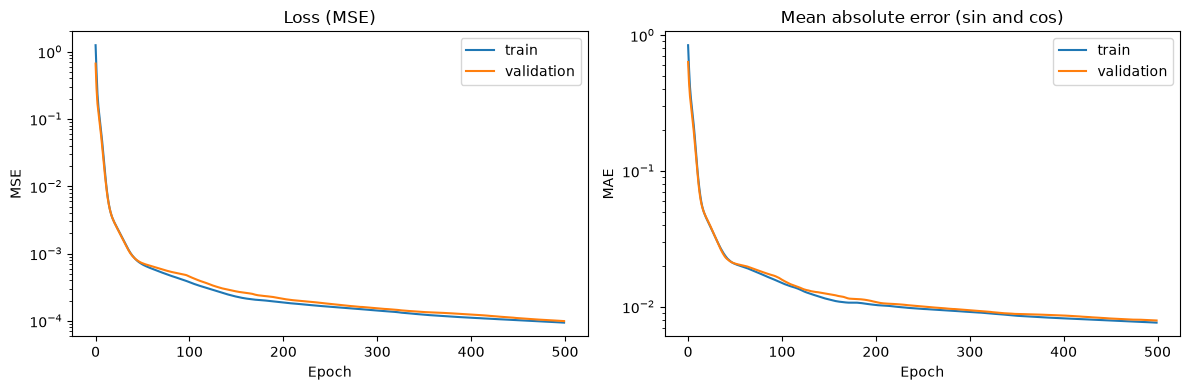

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"], label="train")
ax1.plot(history.history["val_loss"], label="validation")
ax1.set_yscale("log")
ax1.set(title="Loss (MSE)", xlabel="Epoch", ylabel="MSE")
ax1.legend()

ax2.plot(history.history["mae"], label="train")
ax2.plot(history.history["val_mae"], label="validation")
ax2.set_yscale("log")
ax2.set(title="Mean absolute error (sin and cos)", xlabel="Epoch", ylabel="MAE")
ax2.legend()

fig.tight_layout()
fig.savefig(PLOT_PATH, dpi=150)
plt.show()

## 6. Evaluation and Statistical Performance Analysis

Accuracy is reported two ways:

- **Error statistics per function** – MAE, RMSE, bias, standard deviation, maximum and 95th-percentile absolute error, and R².
- **Overall accuracy** = 1 − (mean Euclidean distance between the predicted and true (sin, cos) pair) / 2. Both values lie in [−1, 1], so the largest possible distance is 2.

The **test set** was never used for fitting or for early stopping, so it gives the unbiased estimate. A bootstrap (2000 resamples) gives a 95% confidence interval for the test MAE.

In [8]:
def error_stats(y_true, y_pred):
    err = y_pred - y_true
    distance = np.linalg.norm(err, axis=1)
    stats = {"accuracy": (1.0 - distance.mean() / 2.0) * 100.0, "max_error": np.abs(err).max()}
    for i, name in enumerate(("sin", "cos")):
        e = err[:, i]
        ss_res = np.sum(e ** 2)
        ss_tot = np.sum((y_true[:, i] - y_true[:, i].mean()) ** 2)
        stats[name] = {
            "MAE": np.abs(e).mean(),
            "RMSE": np.sqrt(np.mean(e ** 2)),
            "Bias (mean error)": e.mean(),
            "Std of error": e.std(),
            "Max |error|": np.abs(e).max(),
            "95th pct |error|": np.percentile(np.abs(e), 95),
            "R^2": 1.0 - ss_res / ss_tot,
        }
    return stats

datasets = {"Train": (X_train, y_train), "Validation": (X_val, y_val), "Test (held out)": (X_test, y_test)}
all_stats = {name: error_stats(y, model.predict(X, verbose=0)) for name, (X, y) in datasets.items()}

print(f"{'Dataset':<16}{'MAE sin':>10}{'MAE cos':>10}{'Max error':>11}{'Accuracy':>10}")
for name, s in all_stats.items():
    print(f"{name:<16}{s['sin']['MAE']:>10.5f}{s['cos']['MAE']:>10.5f}{s['max_error']:>11.5f}{s['accuracy']:>9.2f}%")

test_stats = all_stats["Test (held out)"]
print("\nDetailed statistics on the held-out test set")
print(f"{'Metric':<20}{'sin(x)':>12}{'cos(x)':>12}")
for metric in test_stats["sin"]:
    print(f"{metric:<20}{test_stats['sin'][metric]:>12.5f}{test_stats['cos'][metric]:>12.5f}")

def bootstrap_ci(values, n_boot=2000, seed=0):
    r = np.random.default_rng(seed)
    means = [r.choice(values, len(values)).mean() for _ in range(n_boot)]
    return np.percentile(means, [2.5, 97.5])

print()
y_test_pred = model.predict(X_test, verbose=0)
for i, name in enumerate(("sin", "cos")):
    lo, hi = bootstrap_ci(np.abs(y_test_pred[:, i] - y_test[:, i]))
    print(f"95% bootstrap CI for test MAE ({name}): [{lo:.5f}, {hi:.5f}]")

Dataset            MAE sin   MAE cos  Max error  Accuracy
Train              0.00661   0.00814    0.03388    99.42%
Validation         0.00747   0.00834    0.03527    99.38%
Test (held out)    0.00673   0.00784    0.03252    99.43%

Detailed statistics on the held-out test set
Metric                    sin(x)      cos(x)
MAE                      0.00673     0.00784
RMSE                     0.00849     0.01012
Bias (mean error)        0.00117    -0.00390
Std of error             0.00840     0.00934
Max |error|              0.03183     0.03252
95th pct |error|         0.01561     0.02073
R^2                      0.99985     0.99980

95% bootstrap CI for test MAE (sin): [0.00616, 0.00733]
95% bootstrap CI for test MAE (cos): [0.00713, 0.00860]


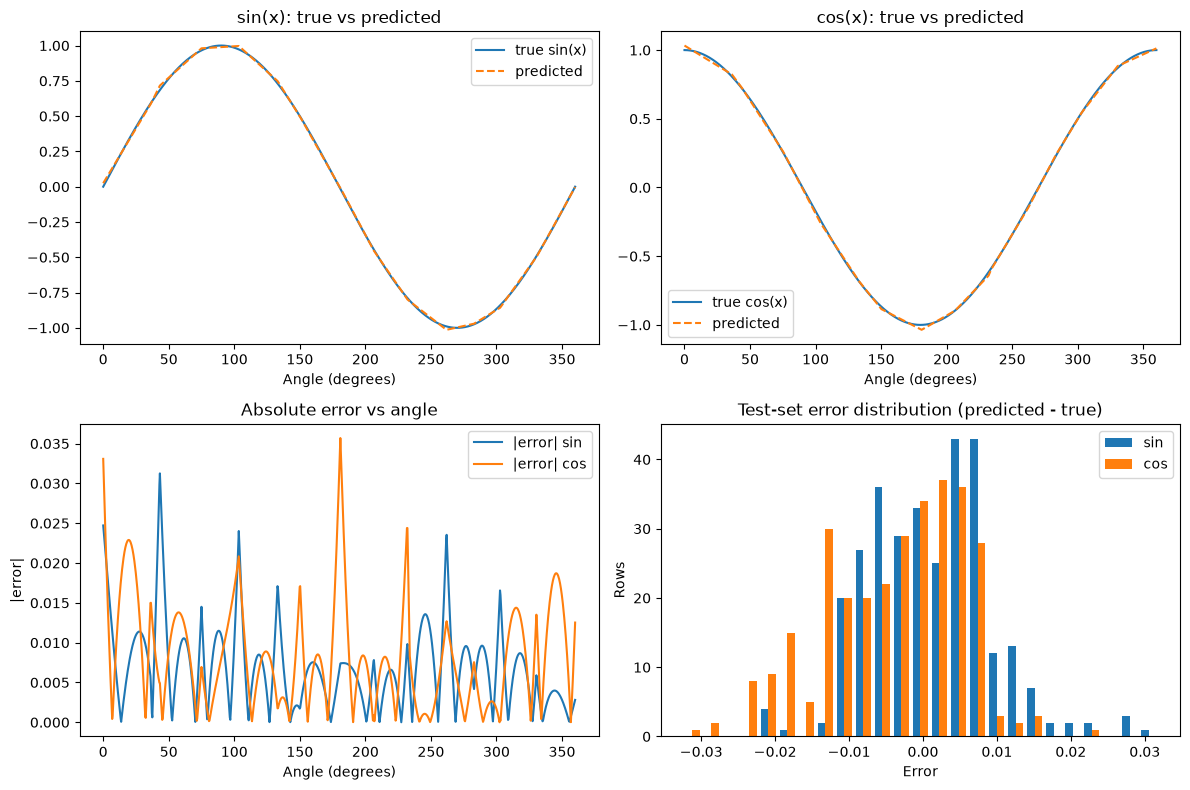

In [9]:
# Dense sweep across one full period, to see where the model is accurate and where it is not
sweep_rad = np.linspace(0.0, TWO_PI, 1000, dtype=np.float32)
sweep_deg = np.rad2deg(sweep_rad)
sweep_true = trig(sweep_rad)
sweep_pred = model.predict(sweep_rad.reshape(-1, 1), verbose=0)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(sweep_deg, sweep_true[:, 0], label="true sin(x)")
axes[0, 0].plot(sweep_deg, sweep_pred[:, 0], "--", label="predicted")
axes[0, 0].set(title="sin(x): true vs predicted", xlabel="Angle (degrees)")
axes[0, 0].legend()

axes[0, 1].plot(sweep_deg, sweep_true[:, 1], label="true cos(x)")
axes[0, 1].plot(sweep_deg, sweep_pred[:, 1], "--", label="predicted")
axes[0, 1].set(title="cos(x): true vs predicted", xlabel="Angle (degrees)")
axes[0, 1].legend()

axes[1, 0].plot(sweep_deg, np.abs(sweep_pred[:, 0] - sweep_true[:, 0]), label="|error| sin")
axes[1, 0].plot(sweep_deg, np.abs(sweep_pred[:, 1] - sweep_true[:, 1]), label="|error| cos")
axes[1, 0].set(title="Absolute error vs angle", xlabel="Angle (degrees)", ylabel="|error|")
axes[1, 0].legend()

axes[1, 1].hist([y_test_pred[:, 0] - y_test[:, 0], y_test_pred[:, 1] - y_test[:, 1]], bins=25,
                label=["sin", "cos"])
axes[1, 1].set(title="Test-set error distribution (predicted - true)", xlabel="Error", ylabel="Rows")
axes[1, 1].legend()

fig.tight_layout()
plt.show()

## 7. Conversion to TensorFlow Lite (Step 4)

The trained Keras model is converted to TensorFlow Lite format in two variants:

- **float32** – same numbers as the Keras model, in a compact file.
- **int8 (quantised)** – weights and activations stored as 8-bit integers, which reduces size and is the usual format for microcontrollers. The input and output are also int8, so an angle in radians is mapped onto 256 levels on the way in, and the results are mapped back on the way out. A representative sweep of angles over [0, 2π] is used to calibrate the quantisation.

The int8 model is also exported as a C array (`model_data.h`) to be compiled into the Arduino sketch.

In [10]:
def convert_to_tflite(model):
    """Return (float32 model bytes, int8-quantised model bytes)."""
    float_bytes = tf.lite.TFLiteConverter.from_keras_model(model).convert()

    def representative_data():
        for angle in np.linspace(0.0, TWO_PI, 200, dtype=np.float32):   # sweep the whole input range
            yield [np.array([[angle]], dtype=np.float32)]

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_data
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return float_bytes, converter.convert()

def write_c_header(model_bytes, path=HEADER_PATH):
    """Dump a .tflite file as a C array (same layout as the Arduino TFLite examples)."""
    rows = ["  " + ", ".join(f"0x{b:02x}" for b in model_bytes[i:i + 12]) for i in range(0, len(model_bytes), 12)]
    with open(path, "w") as f:
        f.write("// Auto-generated - do not edit by hand\n")
        f.write("#ifndef MODEL_DATA_H\n#define MODEL_DATA_H\n\n")
        f.write("alignas(8) const unsigned char g_model[] = {\n" + ",\n".join(rows) + "\n};\n")
        f.write(f"const unsigned int g_model_len = {len(model_bytes)};\n\n")
        f.write("#endif  // MODEL_DATA_H\n")

model.save(KERAS_PATH)
float_bytes, int8_bytes = convert_to_tflite(model)

with open(TFLITE_PATH, "wb") as f:
    f.write(float_bytes)
with open(TFLITE_INT8_PATH, "wb") as f:
    f.write(int8_bytes)
write_c_header(int8_bytes)

print(f"{KERAS_PATH:<24}{os.path.getsize(KERAS_PATH):>8} bytes")
print(f"{TFLITE_PATH:<24}{len(float_bytes):>8} bytes")
print(f"{TFLITE_INT8_PATH:<24}{len(int8_bytes):>8} bytes")
print(f"C array written to {HEADER_PATH}")

INFO:tensorflow:Assets written to: C:\Users\noahm\AppData\Local\Temp\tmpakeexw__\assets


INFO:tensorflow:Assets written to: C:\Users\noahm\AppData\Local\Temp\tmpakeexw__\assets


Saved artifact at 'C:\Users\noahm\AppData\Local\Temp\tmpakeexw__'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_9')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  1826149394064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1826149389648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1826149385616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1826149395792: TensorSpec(shape=(), dtype=tf.resource, name=None)
INFO:tensorflow:Assets written to: C:\Users\noahm\AppData\Local\Temp\tmp_qj7pvln\assets


INFO:tensorflow:Assets written to: C:\Users\noahm\AppData\Local\Temp\tmp_qj7pvln\assets


Saved artifact at 'C:\Users\noahm\AppData\Local\Temp\tmp_qj7pvln'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_9')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  1826149394064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1826149389648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1826149385616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1826149395792: TensorSpec(shape=(), dtype=tf.resource, name=None)
trig_model.keras           21823 bytes
trig_model.tflite           1824 bytes
trig_model_int8.tflite      2312 bytes
C array written to model_data.h


c:\Users\noahm\Desktop\CST440_3\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


## 8. The Application and Testing (Steps 4–5)

The application loads a `.tflite` model, takes an **angle in degrees** from the user, converts it to radians, runs inference and displays the predicted sin(x) and cos(x) next to the true values.

Two details matter for correctness:

- **Angle wrapping.** The model only saw angles between 0 and 2π. A ReLU network extrapolates linearly outside its training range, so any other angle would give a wrong answer. The application first reduces the angle into 0–360° (for example 450° becomes 90°, and −45° becomes 315°). The Arduino code must do the same.
- **Quantisation.** For the int8 model the input is quantised (`q = round(x / scale + zero_point)`) and the outputs are dequantised (`y = (q − zero_point) × scale`) using the parameters stored in the model.

In [11]:
class TrigModel:
    """Thin wrapper around a .tflite model (handles float32 and int8 models)."""

    def __init__(self, path):
        self.path = path
        self.size_bytes = os.path.getsize(path)
        self.interpreter = tf.lite.Interpreter(model_path=path)
        self.interpreter.allocate_tensors()
        self.inp = self.interpreter.get_input_details()[0]
        self.out = self.interpreter.get_output_details()[0]

    def predict(self, angle_rad):
        """Return (sin, cos) predicted for an angle in radians (must be within 0..2*pi)."""
        x = np.float32(angle_rad)
        if self.inp["dtype"] == np.int8:                 # quantise the input
            scale, zero_point = self.inp["quantization"]
            x = np.clip(np.round(x / scale + zero_point), -128, 127)
        self.interpreter.set_tensor(self.inp["index"], np.array([[x]], dtype=self.inp["dtype"]))
        self.interpreter.invoke()
        y = self.interpreter.get_tensor(self.out["index"])[0].astype(np.float32)
        if self.out["dtype"] == np.int8:                 # dequantise the output
            scale, zero_point = self.out["quantization"]
            y = (y - zero_point) * scale
        return float(y[0]), float(y[1])

def wrap_angle(angle_rad):
    """Reduce any angle into 0..2*pi, the range the model was trained on."""
    return float(angle_rad % TWO_PI)

def true_values(angle_rad):
    return float(np.sin(angle_rad)), float(np.cos(angle_rad))

def accuracy_pct(pred, true):
    """1 - (Euclidean distance between predicted and true (sin, cos)) / 2, as a percentage."""
    return (1.0 - np.hypot(pred[0] - true[0], pred[1] - true[1]) / 2.0) * 100.0

tfl_float = TrigModel(TFLITE_PATH)
tfl_int8 = TrigModel(TFLITE_INT8_PATH)
print("Loaded", tfl_float.path, "and", tfl_int8.path)

Loaded trig_model.tflite and trig_model_int8.tflite


c:\Users\noahm\Desktop\CST440_3\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


### 8.1 Accuracy, size and speed of the three model versions

The Keras model and both TensorFlow Lite versions are compared on the held-out test set and on a dense sweep of 1000 angles. Timing is measured on this computer, **not** on the Arduino, so it only shows relative cost.

In [12]:
def summarize(preds, truth):
    err = np.abs(preds - truth)
    distance = np.linalg.norm(preds - truth, axis=1)
    return err[:, 0].mean(), err[:, 1].mean(), err.max(), (1.0 - distance.mean() / 2.0) * 100.0

def tflite_predict_all(tfl, angles_rad):
    start = time.perf_counter()
    preds = np.array([tfl.predict(a) for a in angles_rad])
    ms_per_call = (time.perf_counter() - start) / len(angles_rad) * 1000
    return preds, ms_per_call

comparison = {}
eval_sets = {
    "Held-out test set": (X_test[:, 0], y_test),
    "Dense sweep (1000 angles)": (sweep_rad, sweep_true),
}

for set_name, (angles, truth) in eval_sets.items():
    keras_preds = model.predict(angles.reshape(-1, 1), verbose=0)
    float_preds, float_ms = tflite_predict_all(tfl_float, angles)
    int8_preds, int8_ms = tflite_predict_all(tfl_int8, angles)

    comparison[set_name] = {
        "Keras (float32)": (summarize(keras_preds, truth), None, os.path.getsize(KERAS_PATH)),
        "TFLite float32": (summarize(float_preds, truth), float_ms, tfl_float.size_bytes),
        "TFLite int8": (summarize(int8_preds, truth), int8_ms, tfl_int8.size_bytes),
    }

    print(f"\n{set_name}")
    print(f"{'Model':<18}{'Size (B)':>10}{'MAE sin':>10}{'MAE cos':>10}{'Max err':>10}{'Accuracy':>10}{'ms/call':>10}")
    for name, ((mae_s, mae_c, max_e, acc), ms, size) in comparison[set_name].items():
        ms_text = f"{ms:>10.4f}" if ms is not None else f"{'-':>10}"
        print(f"{name:<18}{size:>10}{mae_s:>10.5f}{mae_c:>10.5f}{max_e:>10.5f}{acc:>9.2f}%{ms_text}")


Held-out test set
Model               Size (B)   MAE sin   MAE cos   Max err  Accuracy   ms/call
Keras (float32)        21823   0.00673   0.00784   0.03252    99.43%         -
TFLite float32          1824   0.00673   0.00784   0.03252    99.43%    0.0036
TFLite int8             2312   0.01064   0.01045   0.04679    99.19%    0.0086

Dense sweep (1000 angles)
Model               Size (B)   MAE sin   MAE cos   Max err  Accuracy   ms/call
Keras (float32)        21823   0.00688   0.00824   0.03569    99.41%         -
TFLite float32          1824   0.00688   0.00824   0.03569    99.41%    0.0033
TFLite int8             2312   0.00987   0.00996   0.04502    99.23%    0.0085


### 8.2 Edge cases

Known values at the angles the lecture lists (0°, 90°, 180°, 270°, …), plus 450° and −90° to check the angle wrapping.

In [13]:
print(f"{'Angle (deg)':>11} | {'sin true':>9} {'sin f32':>9} {'sin int8':>9} | {'cos true':>9} {'cos f32':>9} {'cos int8':>9}")
for deg in [0, 30, 45, 90, 180, 270, 360, 450, -90]:
    rad = wrap_angle(np.deg2rad(deg))
    ts, tc = true_values(rad)
    fs, fc = tfl_float.predict(rad)
    qs, qc = tfl_int8.predict(rad)
    print(f"{deg:>11} | {ts:>9.5f} {fs:>9.5f} {qs:>9.5f} | {tc:>9.5f} {fc:>9.5f} {qc:>9.5f}")

Angle (deg) |  sin true   sin f32  sin int8 |  cos true   cos f32  cos int8
          0 |   0.00000   0.02472   0.03245 |   1.00000   1.03308   1.03028
         30 |   0.50000   0.48905   0.49486 |   0.86603   0.85872   0.86803
         45 |   0.70711   0.73097   0.72201 |   0.70711   0.70752   0.70578
         90 |   1.00000   0.98904   0.99783 |   0.00000  -0.00798  -0.00811
        180 |   0.00000   0.00643  -0.00811 |  -1.00000  -1.03116  -1.02217
        270 |  -1.00000  -0.99733  -0.99783 |  -0.00000  -0.00529  -0.00811
        360 |   0.00000   0.02472   0.03245 |   1.00000   1.03308   1.03028
        450 |   1.00000   0.98904   0.99783 |   0.00000  -0.00798  -0.00811
        -90 |  -1.00000  -0.99733  -0.99783 |  -0.00000  -0.00529  -0.00811


### 8.3 Running the application

`show_result` prints the result for one angle, and `run_interactive` repeats it in a loop that asks for degrees until you type `exit`. The interactive loop waits for keyboard input, so it is switched off by default; set `RUN_INTERACTIVE = True` and run the cell to try it.

In [14]:
def show_result(tfl, angle_deg):
    angle_rad = np.deg2rad(angle_deg)      # the model works in radians internally
    wrapped = wrap_angle(angle_rad)

    start = time.perf_counter()
    pred_sin, pred_cos = tfl.predict(wrapped)
    elapsed_ms = (time.perf_counter() - start) * 1000
    true_sin, true_cos = true_values(wrapped)

    print("=== Result ===")
    print(f"Angle (degrees):     {angle_deg}")
    if not np.isclose(wrapped, angle_rad):
        print(f"Wrapped into 0-360:  {np.rad2deg(wrapped):.4f} degrees")
    print(f"Angle (radians):     {wrapped:.6f}")
    print(f"Predicted sin(x):    {pred_sin:.6f}")
    print(f"Actual sin(x):       {true_sin:.6f}")
    print(f"Predicted cos(x):    {pred_cos:.6f}")
    print(f"Actual cos(x):       {true_cos:.6f}")
    print(f"Absolute error:      sin {abs(pred_sin - true_sin):.6f} | cos {abs(pred_cos - true_cos):.6f}")
    print(f"Model accuracy:      {accuracy_pct((pred_sin, pred_cos), (true_sin, true_cos)):.2f}%")
    print(f"Inference time:      {elapsed_ms:.3f} ms (on this computer)\n")

def run_interactive(tfl):
    print("=== Trig Function Approximation: sin(x) and cos(x) ===")
    print("Enter angles in DEGREES. Type 'exit' to quit.\n")
    while True:
        text = input("Angle (degrees): ").strip()
        if text.lower() == "exit":
            break
        try:
            angle_deg = float(text)
        except ValueError:
            print("Invalid input. Please enter a number.")
            continue
        show_result(tfl, angle_deg)

# Example runs with the int8 model (the version that goes on the Arduino)
show_result(tfl_int8, 90)
show_result(tfl_int8, 450)

RUN_INTERACTIVE = False
if RUN_INTERACTIVE:
    run_interactive(tfl_int8)

=== Result ===
Angle (degrees):     90
Angle (radians):     1.570796
Predicted sin(x):    0.997829
Actual sin(x):       1.000000
Predicted cos(x):    -0.008112
Actual cos(x):       0.000000
Absolute error:      sin 0.002171 | cos 0.008112
Model accuracy:      99.58%
Inference time:      0.095 ms (on this computer)

=== Result ===
Angle (degrees):     450
Wrapped into 0-360:  90.0000 degrees
Angle (radians):     1.570796
Predicted sin(x):    0.997829
Actual sin(x):       1.000000
Predicted cos(x):    -0.008112
Actual cos(x):       0.000000
Absolute error:      sin 0.002171 | cos 0.008112
Model accuracy:      99.58%
Inference time:      0.043 ms (on this computer)



## 9. Deployment to the Arduino (Step 6)

*This section is completed after flashing the board: it records the process and the evidence. Follow the board and library instructions given for the course.*

**Process**

1. Prepare the Arduino Nano and install the TensorFlow Lite library for Arduino in the Arduino IDE.
2. Add `model_data.h` (written in Section 7 from the int8 model) to the sketch folder.
3. Write the sketch so that it:
   - reads an angle in degrees (for example over the Serial Monitor),
   - converts it to radians and wraps it into 0–2π (as in Section 8),
   - quantises the input using the input tensor's scale and zero point, runs inference, and dequantises the two outputs,
   - prints the predicted sin(x) and cos(x) to the Serial Monitor or LCD.
4. Compile, upload, and capture the output on the screen or another computer.

**Evidence** *(replace the placeholders)*

> *Screenshot: Arduino IDE showing a successful compile and upload*
>
> *Screenshot: Serial Monitor output for 0°, 30°, 45°, 90°, 180°, 270°*

**On-device measurements** *(fill in from your board)*

| Measurement | Value |
|---|---|
| Model size in flash (`g_model_len`) | *see Section 7* |
| Tensor arena size used | *(fill in)* |
| Inference time on the Arduino | *(fill in)* |
| Predictions vs. the Python int8 model (Section 8.2) | *(fill in: same / differences)* |

## 10. Discussion and Conclusion

### 10.1 Results summary

The cell below collects the key numbers from the earlier sections so they can be quoted in the discussion.

In [15]:
test_set = comparison["Held-out test set"]
print("Held-out test set")
print(f"  Keras model:      MAE sin {test_set['Keras (float32)'][0][0]:.5f}, MAE cos {test_set['Keras (float32)'][0][1]:.5f}, "
      f"accuracy {test_set['Keras (float32)'][0][3]:.2f}%")
print(f"  TFLite float32:   accuracy {test_set['TFLite float32'][0][3]:.2f}%, size {test_set['TFLite float32'][2]} bytes")
print(f"  TFLite int8:      accuracy {test_set['TFLite int8'][0][3]:.2f}%, size {test_set['TFLite int8'][2]} bytes")
print(f"Training: {epochs_run} epochs, best validation loss at epoch {best_epoch}")
print(f"Initialisation experiment (validation MAE): default {init_results[False]:.5f} vs spread-kink {init_results[True]:.5f}")

Held-out test set
  Keras model:      MAE sin 0.00673, MAE cos 0.00784, accuracy 99.43%
  TFLite float32:   accuracy 99.43%, size 1824 bytes
  TFLite int8:      accuracy 99.19%, size 2312 bytes
Training: 500 epochs, best validation loss at epoch 500
Initialisation experiment (validation MAE): default 0.17010 vs spread-kink 0.01242


### 10.2 Discussion

**Piecewise-linear behaviour.** A network with one ReLU hidden layer is a sum of piecewise-linear functions, so 16 hidden neurons can only draw a curve made of about 17 straight segments. A straight segment departs furthest from a curve where the curvature is greatest, which for sin and cos is near the peaks and troughs. The error-versus-angle plot in Section 6 shows whether the trained model behaves this way.

**Number of hidden neurons.** The lecture recommends 8–16 neurons as a balance between accuracy and memory. More neurons would allow more segments and a smaller error, at the cost of flash, RAM and inference time on the Arduino. Two outputs share the same hidden layer, so sin and cos compete for the same 16 neurons.

**Initialisation.** The experiment in Section 4.1 compares the default Keras initialisation with the spread-kink initialisation. *(Add your observed numbers and comment on the difference.)*

**Quantisation.** The int8 model has 256 levels for the input over 0–2π (a step of about 0.0246 rad, or 1.4°) and 256 levels for the output over [−1, 1] (a step of about 0.0078). Rounding the input can change the result by up to half a step (about 0.012, because the slope of sin and cos is at most 1), and rounding the output by up to about 0.004. This sets a floor on the int8 error, which Section 8.1 measures. *(Comment on the accuracy lost versus the size saved.)*

**Input range.** The model is only valid for angles in 0–2π, so the application, and the Arduino code, wrap every angle into that range first. Section 8.2 checks 450° and −90°.

**Limitations.** The test set has 305 rows, and the results come from a single training run with one random seed. The provided CSV values are rounded to 4 decimal places, which adds a small label noise (about 5×10⁻⁵) to those 25 rows. Timing was measured on a computer rather than on the microcontroller.

### 10.3 Conclusion

*(Summarise in a few sentences using your own numbers from 10.1: that a 66-parameter network with 16 ReLU neurons approximated sin(x) and cos(x) to within an MAE of ⟨…⟩ on unseen data; the size of the float32 and int8 TensorFlow Lite models; what the int8 quantisation cost in accuracy; and whether the Arduino output matched the Python results.)*

---

**Files produced by this notebook:** `trigdata_combined.csv`, `trig_model.keras`, `trig_model.tflite`, `trig_model_int8.tflite`, `model_data.h`, `training_history.png`.

**Reference:** CST-440 Lecture 3 slides, *Machine Learning on a Microcontroller*.